# Задание 23. Оконные функции

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, lcm

plt.style.use("seaborn-v0_8-whitegrid")
        


In [17]:
def common_period(freqs_hz):
    fracs = [Fraction(str(f)).limit_denominator() for f in freqs_hz]

    common_den = 1
    for f in fracs:
        common_den = lcm(common_den, f.denominator)

    nums = [f.numerator * (common_den // f.denominator) for f in fracs]
    common_num = nums[0]
    for n in nums[1:]:
        common_num = gcd(common_num, n)

    return Fraction(common_den, common_num)


def build_signal(fs, components, periods):
    freqs = [freq for _, freq in components]
    base_period = common_period(freqs)
    target_duration = float(periods * base_period)
    n = int(round(target_duration * fs))

    t = np.arange(n) / fs
    x = np.zeros(n)
    for amp, freq in components:
        x += amp * np.sin(2 * np.pi * freq * t)

    return t, x, base_period, target_duration


def blackman_harris_window(n):
    if n == 1:
        return np.ones(1)
    k = np.arange(n)
    a0, a1, a2, a3 = 0.35875, 0.48829, 0.14128, 0.01168
    phase = 2 * np.pi * k / (n - 1)
    return a0 - a1 * np.cos(phase) + a2 * np.cos(2 * phase) - a3 * np.cos(3 * phase)


def spectrum(signal, fs, window, zero_pad=8):
    xw = signal * window
    n_fft = len(signal) * zero_pad
    freq = np.fft.rfftfreq(n_fft, d=1 / fs)
    amp = 2 * np.abs(np.fft.rfft(xw, n=n_fft)) / np.sum(window)
    db = 20 * np.log10(np.maximum(amp / amp.max(), 1e-12))
    return freq, amp, db


def show_info(name, fs, components, periods, n, target_duration):
    real_duration = n / fs
    print(f"{name}: N={n}, T_target={target_duration:.6f} c, T_real={real_duration:.6f} c")
    for amp, freq in components:
        print(f"  f={freq} Гц, A={amp}: периодов в окне = {real_duration * freq:.6f}")


def plot_spectra(data, title, xlim=(0, 60), ylim_db=(-140, 5)):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for label, (f, a, d) in data.items():
        axes[0].plot(f, a, linewidth=2, label=label)
        axes[1].plot(f, d, linewidth=2, label=label)

    axes[0].set_title("Амплитудный спектр")
    axes[0].set_xlabel("Частота, Гц")
    axes[0].set_ylabel("Амплитуда")
    axes[0].set_xlim(*xlim)
    axes[0].legend()

    axes[1].set_title("Нормированный спектр, дБ")
    axes[1].set_xlabel("Частота, Гц")
    axes[1].set_ylabel("Уровень, дБ")
    axes[1].set_xlim(*xlim)
    axes[1].set_ylim(*ylim_db)
    axes[1].legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
        


## 1) Два периода 10.1 Гц, fs = 500 Гц

Пункт 1: N=99, T_target=0.198020 c, T_real=0.198000 c
  f=10.1 Гц, A=1.0: периодов в окне = 1.999800


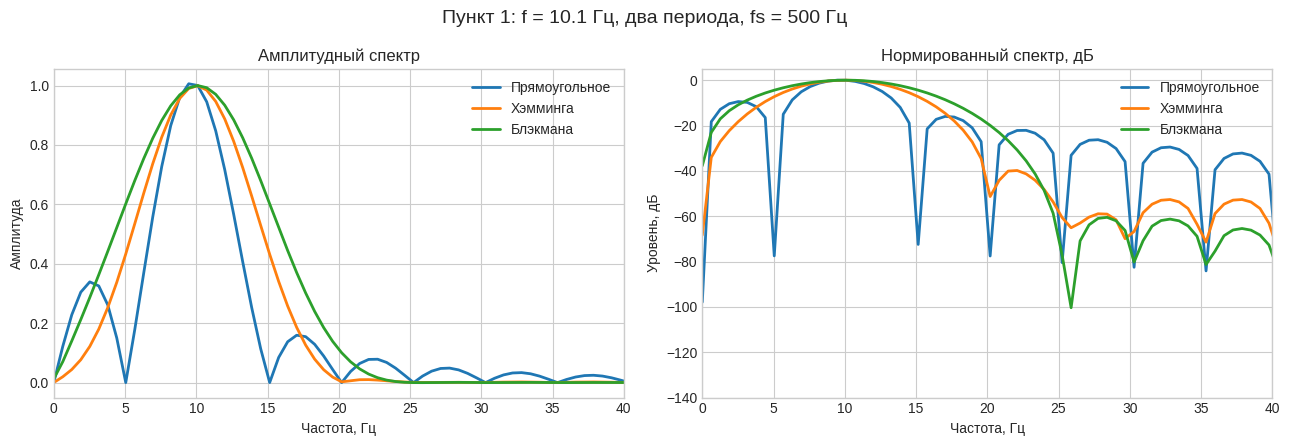

In [18]:
fs = 500
components = [(1.0, 10.1)]
periods = 2

t, signal, base_period, target_duration = build_signal(fs, components, periods)
show_info("Пункт 1", fs, components, periods, len(signal), target_duration)

windows = {
    "Прямоугольное": np.ones_like(signal),
    "Хэмминга": np.hamming(len(signal)),
    "Блэкмана": np.blackman(len(signal)),
}

spectra = {name: spectrum(signal, fs, w) for name, w in windows.items()}
plot_spectra(spectra, "Пункт 1: f = 10.1 Гц, два периода, fs = 500 Гц", xlim=(0, 40))
        


## 2) Один период, 10.1 и 12.3 Гц, fs = 1000 Гц

Пункт 2: N=10000, T_target=10.000000 c, T_real=10.000000 c
  f=10.1 Гц, A=1.0: периодов в окне = 101.000000
  f=12.3 Гц, A=1.0: периодов в окне = 123.000000


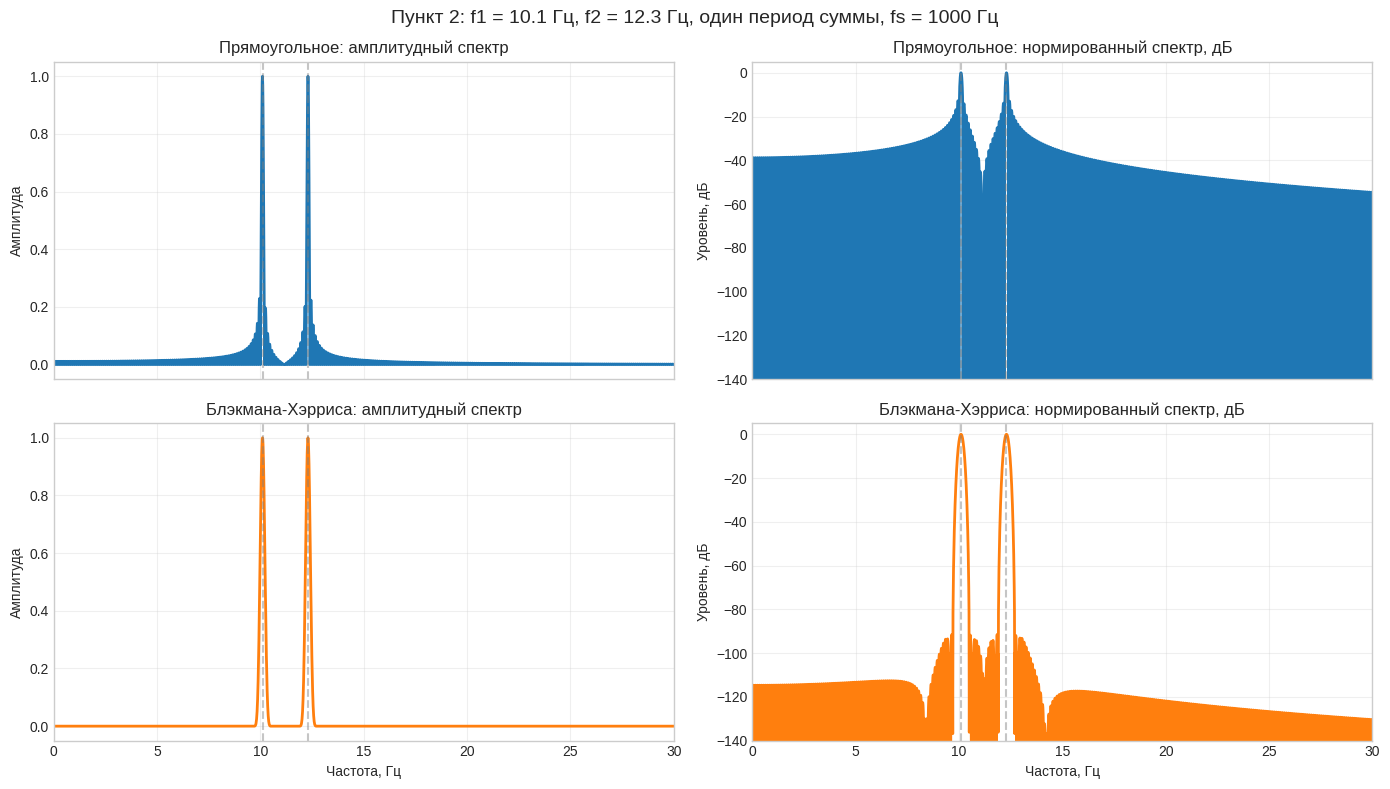

In [19]:
fs = 1000
components = [(1.0, 10.1), (1.0, 12.3)]
periods = 1

t, signal, base_period, target_duration = build_signal(fs, components, periods)
show_info("Пункт 2", fs, components, periods, len(signal), target_duration)

windows = {
    "Прямоугольное": np.ones_like(signal),
    "Блэкмана-Хэрриса": blackman_harris_window(len(signal)),
}

spectra = {name: spectrum(signal, fs, w) for name, w in windows.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
line_colors = ["tab:blue", "tab:orange"]
ref_freqs = [freq for _, freq in components]

for row, ((label, (f, a, d)), color) in enumerate(zip(spectra.items(), line_colors)):
    ax_amp = axes[row, 0]
    ax_db = axes[row, 1]

    ax_amp.plot(f, a, linewidth=2, color=color)
    ax_db.plot(f, d, linewidth=2, color=color)

    for rf in ref_freqs:
        ax_amp.axvline(rf, linestyle="--", color="gray", alpha=0.45)
        ax_db.axvline(rf, linestyle="--", color="gray", alpha=0.45)

    ax_amp.set_title(f"{label}: амплитудный спектр")
    ax_amp.set_ylabel("Амплитуда")
    ax_amp.set_xlim(0, 30)
    ax_amp.grid(True, alpha=0.3)

    ax_db.set_title(f"{label}: нормированный спектр, дБ")
    ax_db.set_ylabel("Уровень, дБ")
    ax_db.set_xlim(0, 30)
    ax_db.set_ylim(-140, 5)
    ax_db.grid(True, alpha=0.3)

axes[1, 0].set_xlabel("Частота, Гц")
axes[1, 1].set_xlabel("Частота, Гц")

fig.suptitle("Пункт 2: f1 = 10.1 Гц, f2 = 12.3 Гц, один период суммы, fs = 1000 Гц", fontsize=14)
plt.tight_layout()
plt.show()


## 3) Один период, 10.1 и 15.2 Гц, амплитуды 1 и 0.025, fs = 1000 Гц

Пункт 3: N=10000, T_target=10.000000 c, T_real=10.000000 c
  f=10.1 Гц, A=1.0: периодов в окне = 101.000000
  f=15.2 Гц, A=0.025: периодов в окне = 152.000000


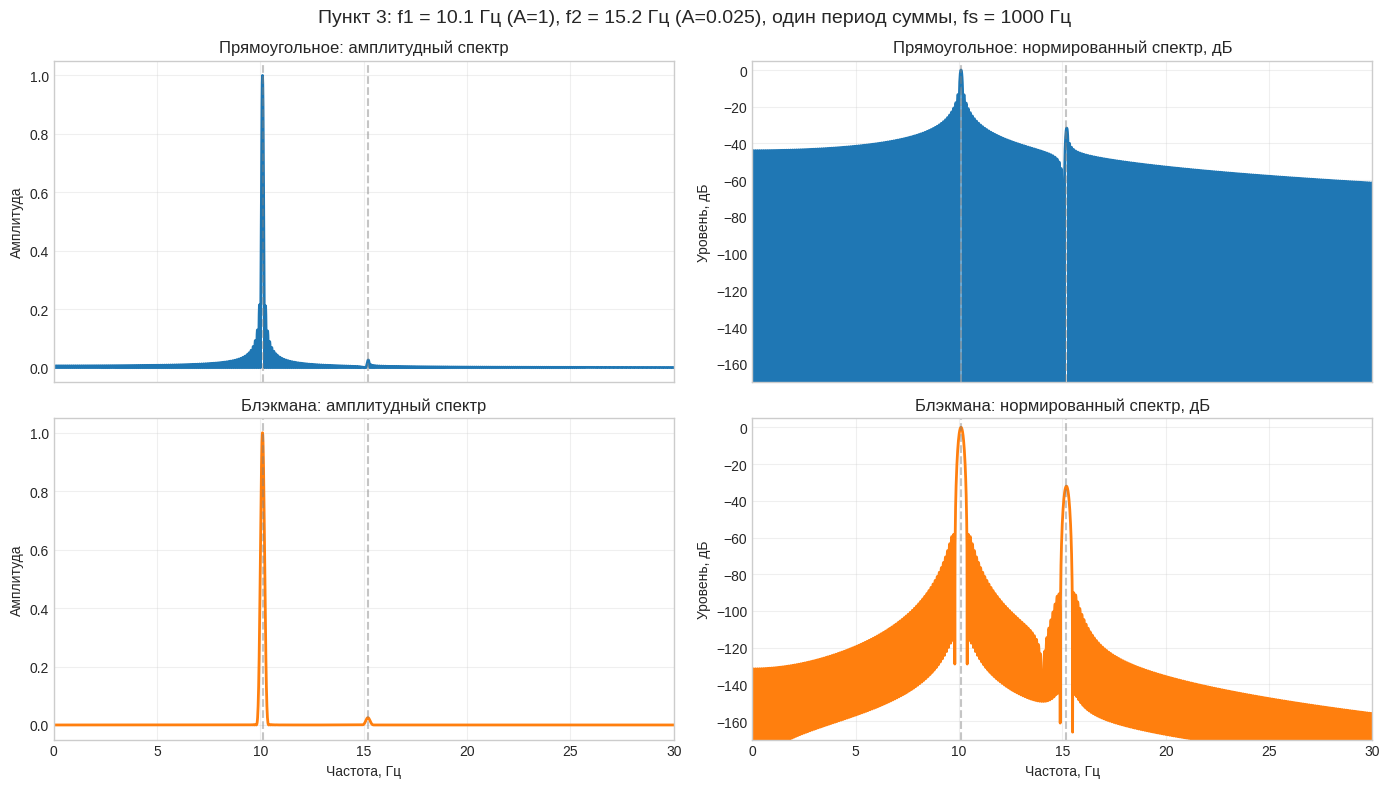

In [20]:
fs = 1000
components = [(1.0, 10.1), (0.025, 15.2)]
periods = 1

t, signal, base_period, target_duration = build_signal(fs, components, periods)
show_info("Пункт 3", fs, components, periods, len(signal), target_duration)

windows = {
    "Прямоугольное": np.ones_like(signal),
    "Блэкмана": np.blackman(len(signal)),
}

spectra = {name: spectrum(signal, fs, w) for name, w in windows.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
line_colors = ["tab:blue", "tab:orange"]
ref_freqs = [freq for _, freq in components]

for row, ((label, (f, a, d)), color) in enumerate(zip(spectra.items(), line_colors)):
    ax_amp = axes[row, 0]
    ax_db = axes[row, 1]

    ax_amp.plot(f, a, linewidth=2, color=color)
    ax_db.plot(f, d, linewidth=2, color=color)

    for rf in ref_freqs:
        ax_amp.axvline(rf, linestyle="--", color="gray", alpha=0.45)
        ax_db.axvline(rf, linestyle="--", color="gray", alpha=0.45)

    ax_amp.set_title(f"{label}: амплитудный спектр")
    ax_amp.set_ylabel("Амплитуда")
    ax_amp.set_xlim(0, 30)
    ax_amp.grid(True, alpha=0.3)

    ax_db.set_title(f"{label}: нормированный спектр, дБ")
    ax_db.set_ylabel("Уровень, дБ")
    ax_db.set_xlim(0, 30)
    ax_db.set_ylim(-170, 5)
    ax_db.grid(True, alpha=0.3)

axes[1, 0].set_xlabel("Частота, Гц")
axes[1, 1].set_xlabel("Частота, Гц")

fig.suptitle(
    "Пункт 3: f1 = 10.1 Гц (A=1), f2 = 15.2 Гц (A=0.025), один период суммы, fs = 1000 Гц",
    fontsize=14,
)
plt.tight_layout()
plt.show()
